In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.model_selection import learning_curve

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
SEED = 42
np.random.seed(SEED)

In [ ]:
X = np.linspace(-3, 3, 100).reshape(-1, 1)

In [ ]:
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

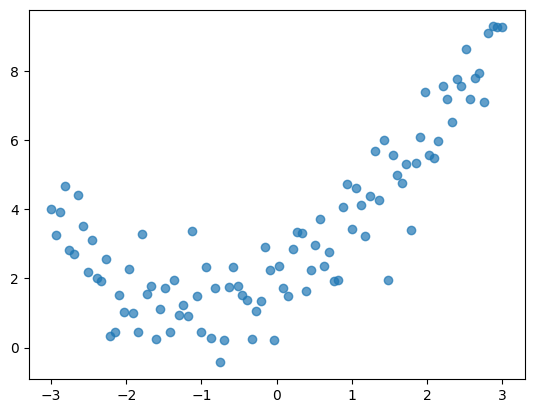

In [ ]:
plt.scatter(X, y, alpha = 0.7)

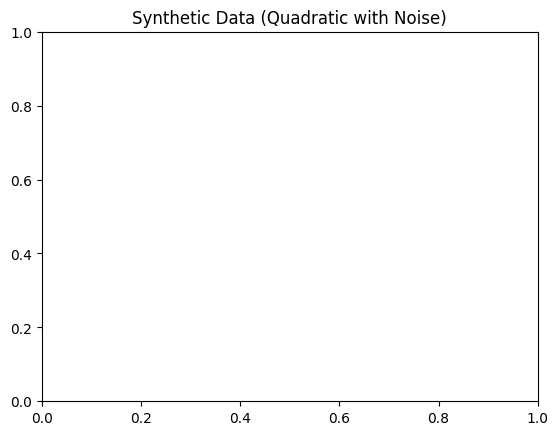

In [ ]:
plt.title("Synthetic Data (Quadratic with Noise)")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = SEED
)

In [ ]:
model = Pipeline([
    ("poly", PolynomialFeatures(degree = 2)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

In [ ]:
model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('scaler', StandardScaler()),
                ('linear', LinearRegression())])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
def train_and_evaluate(degree):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("scaler", StandardScaler()),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)

    y_pred_test = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_pred_train)

    test_mse = mean_squared_error(y_test, y_pred_test)

    r2_train = r2_score(y_train, y_pred_train)

    r2_test = r2_score(y_test, y_pred_test)

    return train_mse, test_mse, r2_train, r2_test

In [ ]:
train_mse, test_mse, r2_train, r2_test = train_and_evaluate(2)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Train R2:", r2_train)
print("Test R2:", r2_test)

degrees = [1, 2, 5, 10]
for degree in degrees:
    train_mse, test_mse, r2_train, r2_test = train_and_evaluate(degree)
    print(f"Degree: {degree}")
    print(f"Train MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Train R²: {r2_train:.4f}")
    print(f"Test R²: {r2_test:.4f}")
    print("-" * 40)

Train MSE: 0.9222220566526338
Test MSE: 0.5570736972964307
Train R2: 0.859984293815657
Test R2: 0.8827064568135388
Degree: 1
Train MSE: 3.0993
Test MSE: 2.2551
Train R²: 0.5294
Test R²: 0.5252
----------------------------------------
Degree: 2
Train MSE: 0.9222
Test MSE: 0.5571
Train R²: 0.8600
Test R²: 0.8827
----------------------------------------
Degree: 5
Train MSE: 0.8583
Test MSE: 0.5551
Train R²: 0.8697
Test R²: 0.8831
----------------------------------------
Degree: 10
Train MSE: 0.7827
Test MSE: 0.7649
Train R²: 0.8812
Test R²: 0.8389
----------------------------------------
